# Optimal transport based dataset similarity

In [32]:
%env LA_PYTHON_CLIENT_MEM_FRACTION=.99

env: LA_PYTHON_CLIENT_MEM_FRACTION=.99


In [2]:
%load_ext autoreload

In [3]:
import warnings
from os.path import join

import anndata
import scanpy as sc
import numpy as np
import pandas as pd

In [4]:
import jax
import jax.numpy as jnp
import jax.scipy

In [5]:
%autoreload
from datasim.dataset_ot import DatasetMapping

## Load data

In [6]:
DATA_PATH = "/vol/data/dataset-similarity"

# load and preprocess data
adata_query, adata_ref = DatasetMapping.preprocess_adatas(
    sc.read_h5ad(join(DATA_PATH, "01ad3cd7-3929-4654-84c0-6db05bd5fd59_processed.h5ad")),
    sc.read_h5ad(join(DATA_PATH, "b0e547f0-462b-4f81-b31b-5b0a5d96f537_processed.h5ad")),
    n_top_genes=1000
)

/vol/data/miniconda3/envs/similarity/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:226: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby("mean_bin")["dispersions"]
/vol/data/miniconda3/envs/similarity/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:226: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby("mean_bin")["dispersions"]
/vol/data/miniconda3/envs/similarity/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:508: FutureWarning: The provided callable <function nanmean at 0x7f16

In [7]:
# sc.pp.subsample(adata_query, fraction=0.75)
# sc.pp.subsample(adata_ref, fraction=0.75)

In [8]:
adata_query

AnnData object with n_obs × n_vars = 600929 × 1000
    obs: 'assay', 'cell_type', 'development_stage', 'disease', 'donor_id', 'is_primary_data', 'sex', 'suspension_type', 'tissue', 'cell_type_author'
    var: 'gene_names'
    uns: 'log1p'

In [9]:
adata_ref

AnnData object with n_obs × n_vars = 1058909 × 1000
    obs: 'assay', 'cell_type', 'development_stage', 'disease', 'donor_id', 'is_primary_data', 'sex', 'suspension_type', 'tissue', 'cell_type_author'
    var: 'gene_names'
    uns: 'log1p'

## Intialize and fit optimal transport model

In [10]:
dataset_map = DatasetMapping(adata_query, adata_ref)

In [11]:
# ignore warnings here as scanpy.tl.rank_genes_groups throws a lot of warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    dataset_map.init_geom(batch_size=1024, epsilon=0.05)

In [12]:
print(f"x size: {dataset_map.geom.x.shape[0] * dataset_map.geom.x.shape[1] * 4 / 1000**3} GB")
print(f"y size: {dataset_map.geom.y.shape[0] * dataset_map.geom.y.shape[1] * 4 / 1000**3} GB")

x size: 2.406119716 GB
y size: 4.239871636 GB


In [13]:
dataset_map.init_problem(tau_a=0.75, tau_b=0.75)

In [14]:
dataset_map.solve();

  1%|█▍                                                                                                                                                  | 2/200 [50:45<83:44:45, 1522.65s/it, error: 9.922100e-04]


## Visualize optimal transport mapping

In [33]:
%autoreload
from datasim.plotting import plot_heatmap, plot_sankey

### Cluster mapping

In [16]:
cluster_mapping = dataset_map.compute_cluster_mapping(normalize=True)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [46:34<00:00, 69.87s/it]


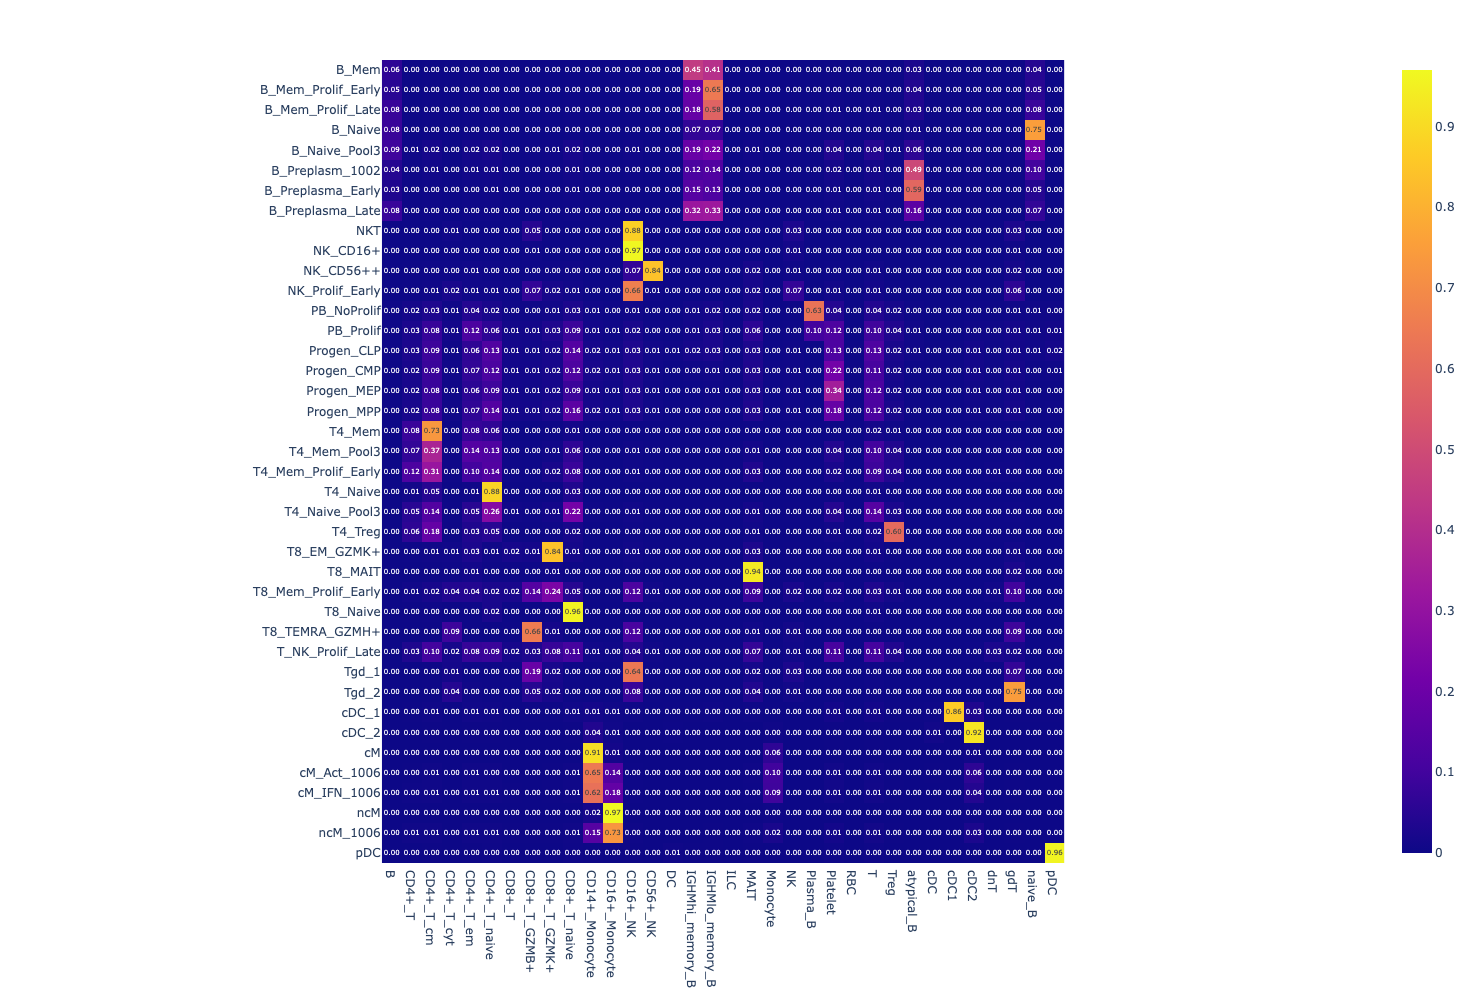

In [34]:
plot_heatmap(cluster_mapping)

### Cluster distances

In [18]:
cluster_distance = dataset_map.compute_cluster_distances(n_samples=25000)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1360/1360 [15:57<00:00,  1.42it/s]


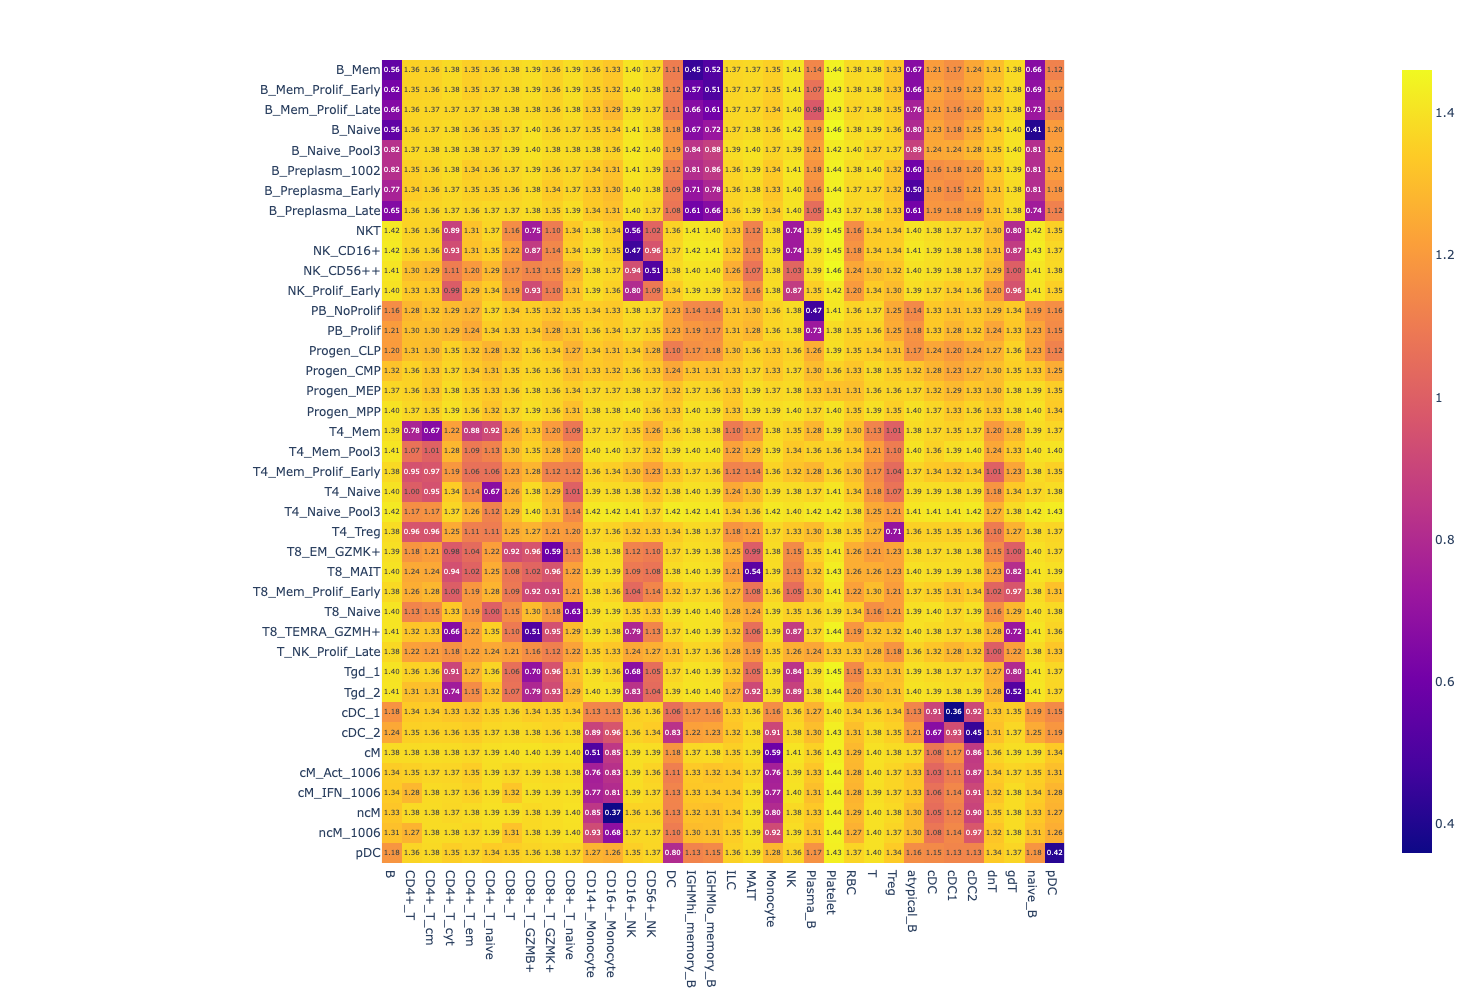

In [35]:
plot_heatmap(cluster_distance, show=True)

### Sankey visualization

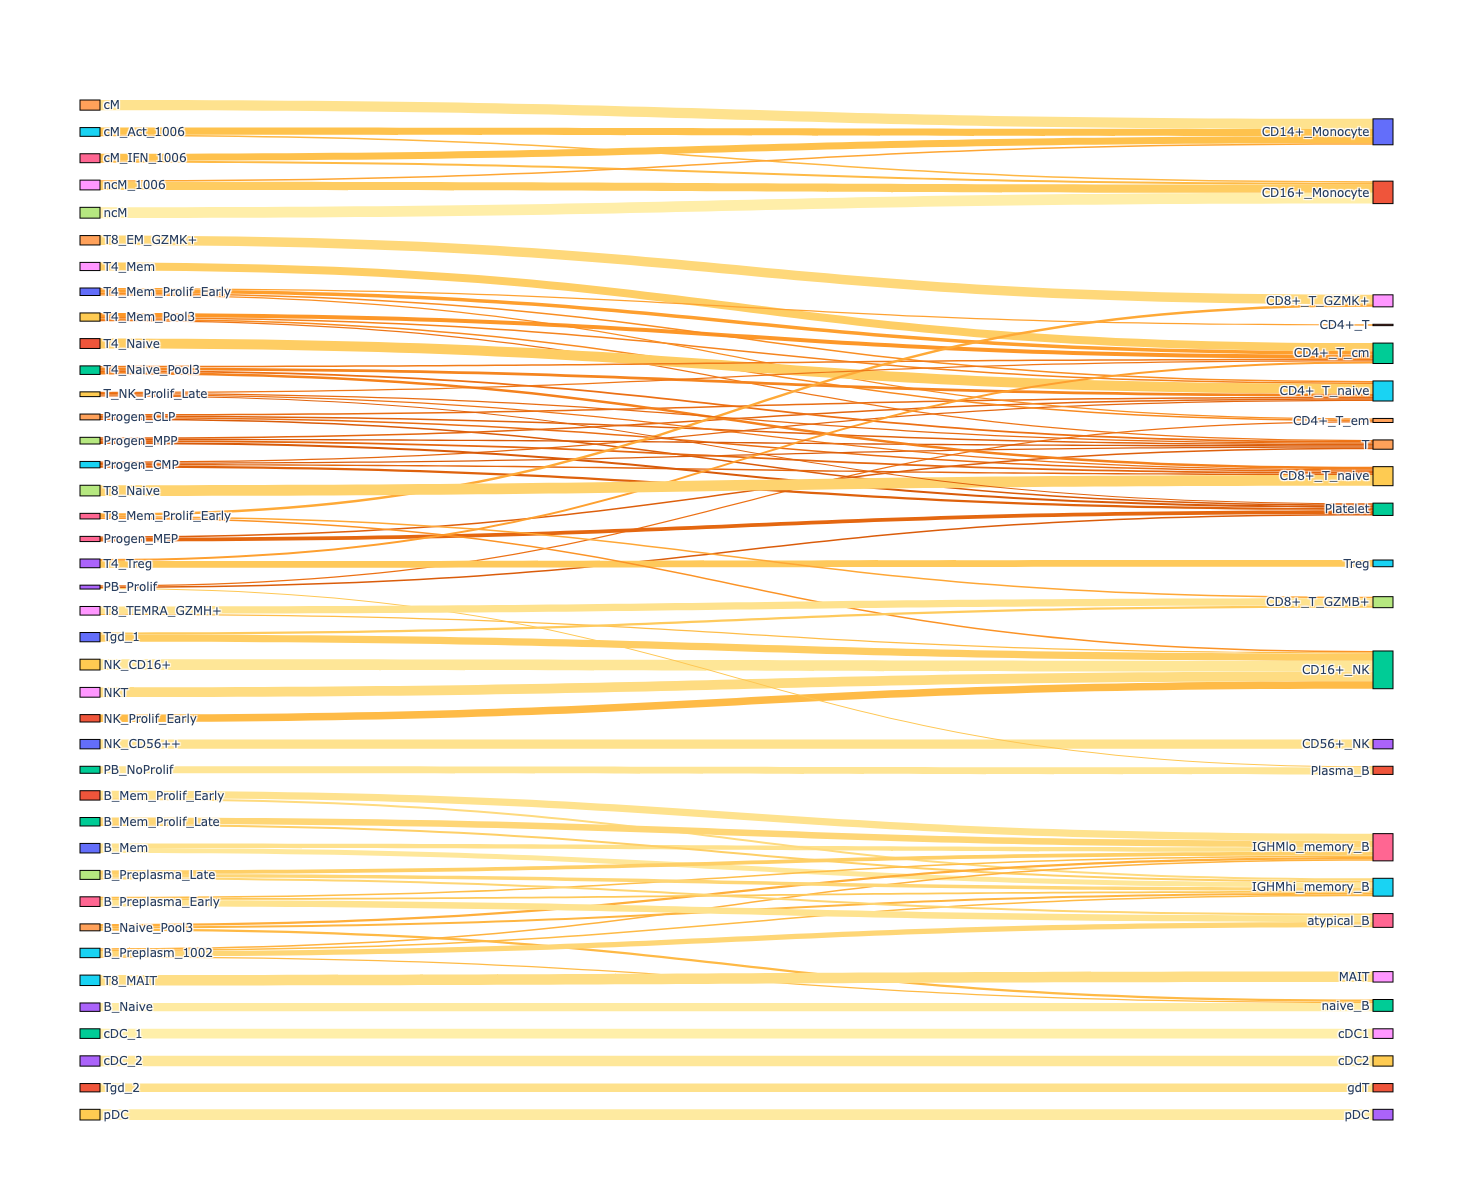

In [36]:
plot_sankey(cluster_mapping, cluster_distance)

### Top n most similar clusters

In [24]:
top_n_labels = DatasetMapping.select_most_similar_clusters(cluster_mapping, threshold=0.1, n_top=5)
top_n_labels

{'B_Mem': ['IGHMhi_memory_B', 'IGHMlo_memory_B'],
 'B_Mem_Prolif_Early': ['IGHMlo_memory_B', 'IGHMhi_memory_B'],
 'B_Mem_Prolif_Late': ['IGHMlo_memory_B', 'IGHMhi_memory_B'],
 'B_Naive': ['naive_B'],
 'B_Naive_Pool3': ['IGHMlo_memory_B', 'naive_B', 'IGHMhi_memory_B'],
 'B_Preplasm_1002': ['atypical_B',
  'IGHMlo_memory_B',
  'IGHMhi_memory_B',
  'naive_B'],
 'B_Preplasma_Early': ['atypical_B', 'IGHMhi_memory_B', 'IGHMlo_memory_B'],
 'B_Preplasma_Late': ['IGHMlo_memory_B', 'IGHMhi_memory_B', 'atypical_B'],
 'NKT': ['CD16+_NK'],
 'NK_CD16+': ['CD16+_NK'],
 'NK_CD56++': ['CD56+_NK'],
 'NK_Prolif_Early': ['CD16+_NK'],
 'PB_NoProlif': ['Plasma_B'],
 'PB_Prolif': ['Platelet', 'CD4+_T_em', 'Plasma_B'],
 'Progen_CLP': ['CD8+_T_naive', 'CD4+_T_naive', 'T', 'Platelet'],
 'Progen_CMP': ['Platelet', 'CD8+_T_naive', 'CD4+_T_naive', 'T'],
 'Progen_MEP': ['Platelet', 'T'],
 'Progen_MPP': ['Platelet', 'CD8+_T_naive', 'CD4+_T_naive', 'T'],
 'T4_Mem': ['CD4+_T_cm'],
 'T4_Mem_Pool3': ['CD4+_T_cm', 'CD4+_